# EDA: competition Vehicle ReID and external datasets

Exploration of the official train/test split and a comparison with **VeRi** / **VRIC**, used here as extra-data pretraining sources.

Task (open-set retrieval): for every crop in `test_query.csv`, rank `test_gallery.csv`. Identity labels exist only in train. License plates and faces are blurred; residual plate cues must not be used.


In [1]:
from pathlib import Path
from xml.etree import ElementTree

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

from dataset.folds import make_folds, query_gallery_split, read_annotations
from dataset.images import crop_bbox, image_path
from dataset.pretrain import read_veri, read_vric

plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "data" / "train.csv").is_file())
DATA = ROOT / "data"
IMAGES = DATA / "images"
EXTRA = ROOT / "extra_data"
RNG = np.random.default_rng(42)
print("ROOT", ROOT)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT /data/projects/ryzhichkin/ReID


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


## 1. Official dataset layout


In [2]:
train = read_annotations(DATA / "train.csv", labeled=True)
query = read_annotations(DATA / "test_query.csv", labeled=False)
gallery = read_annotations(DATA / "test_gallery.csv", labeled=False)
splits = {"train": train, "test_query": query, "test_gallery": gallery}

inventory = pd.DataFrame(
    {
        "split": list(splits),
        "rows": [len(df) for df in splits.values()],
        "unique_image_id": [df.image_id.nunique() for df in splits.values()],
        "columns": [", ".join(df.columns) for df in splits.values()],
        "has_vehicle_id": ["vehicle_id" in df for df in splits.values()],
        "has_camera_id": [
            df.camera_id.ne(-1).any() if "camera_id" in df else False for df in splits.values()
        ],
    }
)
display(inventory)

files = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(ROOT)),
            "exists": path.is_file(),
            "bytes": path.stat().st_size if path.is_file() else 0,
        }
        for path in [
            DATA / "train.csv",
            DATA / "test_query.csv",
            DATA / "test_gallery.csv",
            DATA / "README.md",
            IMAGES,
        ]
    ]
)
image_files = list(IMAGES.glob("*.jpg")) + list(IMAGES.glob("*.jpeg")) + list(IMAGES.glob("*.png"))
print("image files on disk", len(image_files))
display(files)

,split,rows,unique_image_id,columns,has_vehicle_id,has_camera_id
0,train,9556,9556,"image_id, x, y, w, h, vehicle_id, camera_id, r...",True,True
1,test_query,1110,1110,"image_id, x, y, w, h, camera_id, row_id",False,False
2,test_gallery,750,750,"image_id, x, y, w, h, camera_id, row_id",False,False


image files on disk 11416


,path,exists,bytes
0,data/train.csv,True,536677
1,data/test_query.csv,True,54288
2,data/test_gallery.csv,True,36693
3,data/README.md,True,4817
4,data/images,False,0


One CSV row is one object (one bbox per frame). `image_id` has no extension: the loader searches `.jpg` / `.png` / `.jpeg`.

Test is **unlabeled**: no `vehicle_id` or `camera_id`. Train/test is the organizers' split, not GroupKFold.


In [3]:
ids = {name: set(df.image_id) for name, df in splits.items()}
overlap = pd.DataFrame(
    [{"a": a, "b": b, "intersection": len(ids[a] & ids[b])} for a in ids for b in ids if a < b]
)
display(overlap)

all_ids = ids["train"] | ids["test_query"] | ids["test_gallery"]
on_disk = {p.stem for p in image_files}
print("csv image_ids", len(all_ids))
print("missing on disk", len(all_ids - on_disk))
print("extra files on disk", len(on_disk - all_ids))
print("duplicate image_id in any split", any(df.image_id.duplicated().any() for df in splits.values()))
print(
    "NaN in required fields",
    {name: int(df[["image_id", "x", "y", "w", "h"]].isna().sum().sum()) for name, df in splits.items()},
)

,a,b,intersection
0,test_query,train,0
1,test_gallery,train,0
2,test_gallery,test_query,0


csv image_ids 11416
missing on disk 0
extra files on disk 0
duplicate image_id in any split False
NaN in required fields {'train': 0, 'test_query': 0, 'test_gallery': 0}


## 2. Train: identities, cameras, protocol


identities 1541 cameras 96
every identity has >=2 cameras True


,count,mean,std,min,25%,50%,75%,max
n_images,1541.0,6.201168,1.161514,4.0,6.0,6.0,7.0,8.0
n_cameras,1541.0,2.520441,0.909762,2.0,2.0,2.0,3.0,8.0


,count,mean,std,min,25%,50%,75%,max
images_per_camera,96.0,99.541667,151.139665,1.0,31.0,60.5,111.5,1069.0


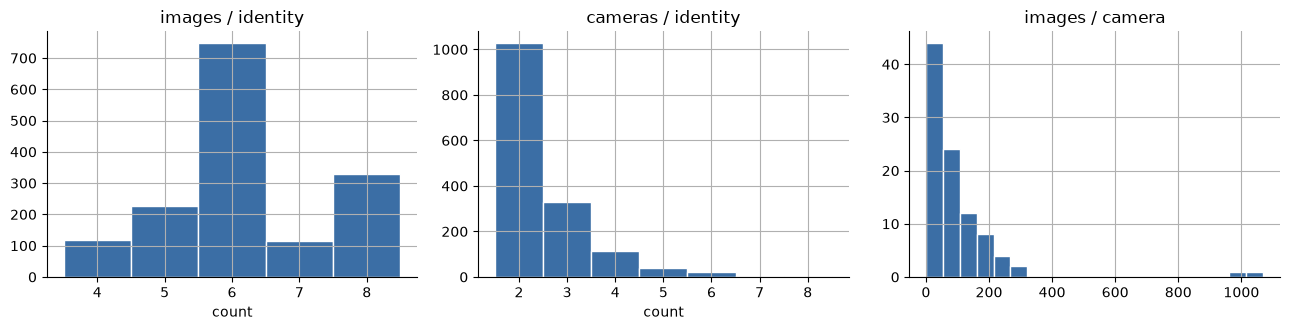

most common camera pairs (same identity):


,n_identities
"(89, 90)",301
"(43, 90)",81
"(82, 85)",75
"(12, 51)",61
"(6, 33)",52
"(6, 19)",48
"(20, 82)",44
"(43, 89)",38
"(68, 77)",37
"(20, 85)",26


In [4]:
per_id = train.groupby("vehicle_id").agg(
    n_images=("image_id", "size"),
    n_cameras=("camera_id", "nunique"),
)
cam_count = train.groupby("camera_id").size().rename("n_images")
print("identities", train.vehicle_id.nunique(), "cameras", train.camera_id.nunique())
print("every identity has >=2 cameras", bool((per_id.n_cameras >= 2).all()))
display(per_id.describe().T)
display(cam_count.describe().to_frame("images_per_camera").T)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(per_id.n_images, bins=np.arange(3.5, 9.5, 1), color="#3b6ea5", edgecolor="white")
axes[0].set_title("images / identity")
axes[0].set_xlabel("count")
axes[1].hist(per_id.n_cameras, bins=np.arange(1.5, 9.5, 1), color="#3b6ea5", edgecolor="white")
axes[1].set_title("cameras / identity")
axes[1].set_xlabel("count")
axes[2].hist(cam_count, bins=20, color="#3b6ea5", edgecolor="white")
axes[2].set_title("images / camera")
fig.tight_layout()
plt.show()

pair_rows = []
for _, rows in train.groupby("vehicle_id"):
    cams = sorted(rows.camera_id.unique())
    for i, a in enumerate(cams):
        for b in cams[i + 1 :]:
            pair_rows.append((a, b))
pairs = pd.Series(pair_rows).value_counts().head(15)
print("most common camera pairs (same identity):")
display(pairs.to_frame("n_identities"))

In [5]:
q_val, g_val = query_gallery_split(train, seed=42, query_per_identity=1, cross_camera=True)
print("internal probe on 100% train.csv (same protocol as pretrain val / zero-shot):")
print(f"  queries={len(q_val)} gallery={len(g_val)} identities={q_val.vehicle_id.nunique()}")
print(
    "  query cameras vs gallery cameras disjoint by construction:",
    set(zip(q_val.vehicle_id, q_val.camera_id, strict=True)).isdisjoint(
        set(zip(g_val.vehicle_id, g_val.camera_id, strict=True))
    ),
)

folded = make_folds(train, n_folds=5, seed=42)
fold_tbl = folded.groupby("fold").agg(
    images=("image_id", "size"),
    identities=("vehicle_id", "nunique"),
)
fold_tbl["train_identities"] = train.vehicle_id.nunique() - fold_tbl.identities
display(fold_tbl)
print("identity leakage across folds", int((folded.groupby("vehicle_id").fold.nunique() > 1).sum()))

internal probe on 100% train.csv (same protocol as pretrain val / zero-shot):
  queries=1541 gallery=5550 identities=1541
  query cameras vs gallery cameras disjoint by construction: True


,images,identities,train_identities
fold,,,
0,1940,309,1232
1,1915,308,1233
2,1898,308,1233
3,1884,308,1233
4,1919,308,1233


identity leakage across folds 0


Internal validation is **GroupKFold on `vehicle_id`**: five folds, no vehicle overlap. On each val fold the query/gallery split takes one query per identity from one camera and puts the remaining images of that vehicle into gallery (cross-camera).

The official test is different: labels are hidden, and **query (1110) is larger than gallery (750)**. That is not the OOF protocol.


## 3. Frame and bbox geometry


In [6]:
def attach_frame_size(df, image_dir):
    out = df.copy()
    heights, widths = [], []
    for image_id in out.image_id:
        with Image.open(image_path(image_dir, image_id)) as im:
            widths.append(im.size[0])
            heights.append(im.size[1])
    out["frame_w"] = widths
    out["frame_h"] = heights
    out["aspect"] = out.w / out.h
    out["bbox_area"] = out.w * out.h
    out["frame_area"] = out.frame_w * out.frame_h
    out["coverage"] = out.bbox_area / out.frame_area
    out["cx"] = (out.x + out.w / 2) / out.frame_w
    out["cy"] = (out.y + out.h / 2) / out.frame_h
    return out


train_g = attach_frame_size(train, IMAGES)
query_g = attach_frame_size(query, IMAGES)
gallery_g = attach_frame_size(gallery, IMAGES)
geom = {"train": train_g, "test_query": query_g, "test_gallery": gallery_g}

rows = []
for name, df in geom.items():
    desc = df[["frame_w", "frame_h", "w", "h", "aspect", "coverage", "cx", "cy"]].describe().T
    desc.insert(0, "split", name)
    rows.append(desc.reset_index().rename(columns={"index": "stat"}))
display(pd.concat(rows, ignore_index=True))

print("unique frame sizes")
for name, df in geom.items():
    print(name, df.groupby(["frame_w", "frame_h"]).size().sort_values(ascending=False).head(8).to_dict())

,stat,split,count,mean,std,min,25%,50%,75%,max
0,frame_w,train,9556.0,1920.000000,0.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000
1,frame_h,train,9556.0,1080.000000,0.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
2,w,train,9556.0,689.674969,189.819644,151.000000,557.000000,669.000000,801.000000,1743.000000
3,h,train,9556.0,499.690247,114.024486,147.000000,417.000000,485.000000,570.000000,1050.000000
4,aspect,train,9556.0,1.398818,0.325402,0.456193,1.153562,1.356887,1.591837,5.586538
5,coverage,train,9556.0,0.172374,0.077718,0.016059,0.116455,0.157178,0.213316,0.588397
6,cx,train,9556.0,0.496549,0.168182,0.080208,0.385156,0.495312,0.598177,0.940885
7,cy,train,9556.0,0.510491,0.133412,0.080556,0.431019,0.525463,0.600926,0.931944
8,frame_w,test_query,1110.0,1920.000000,0.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000
9,frame_h,test_query,1110.0,1080.000000,0.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000


unique frame sizes
train {(1920, 1080): 9556}
test_query {(1920, 1080): 1110}
test_gallery {(1920, 1080): 750}


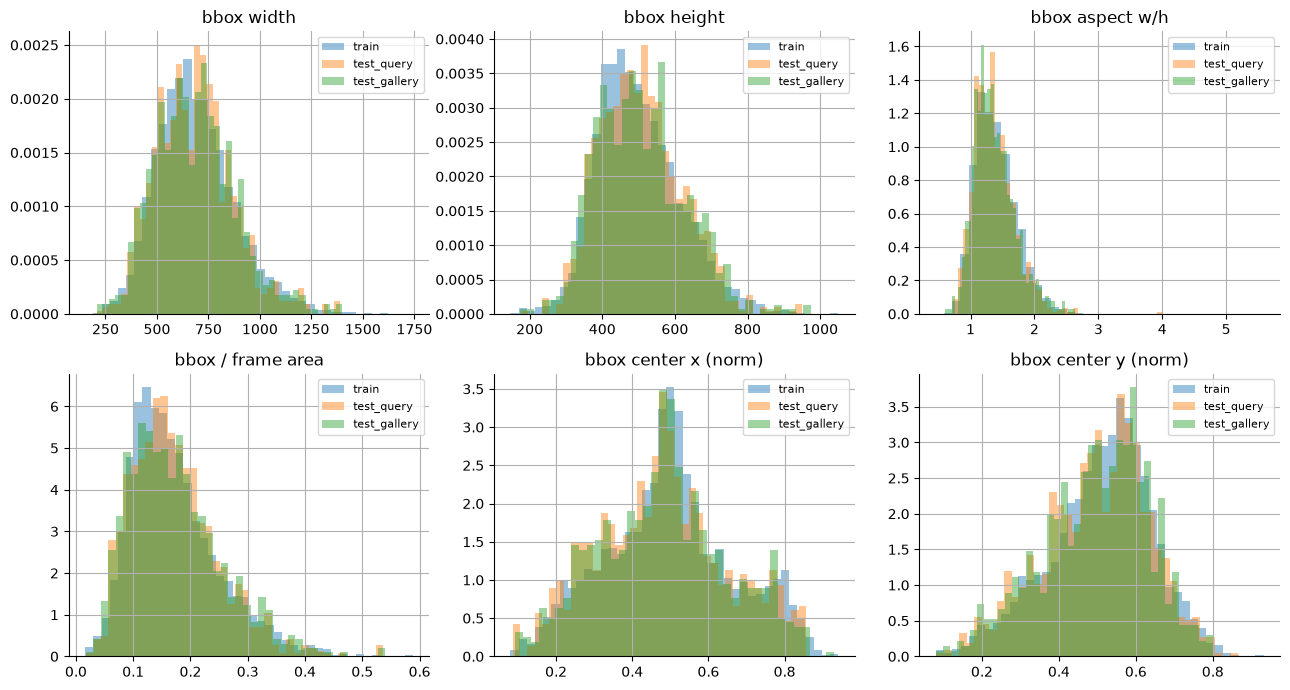

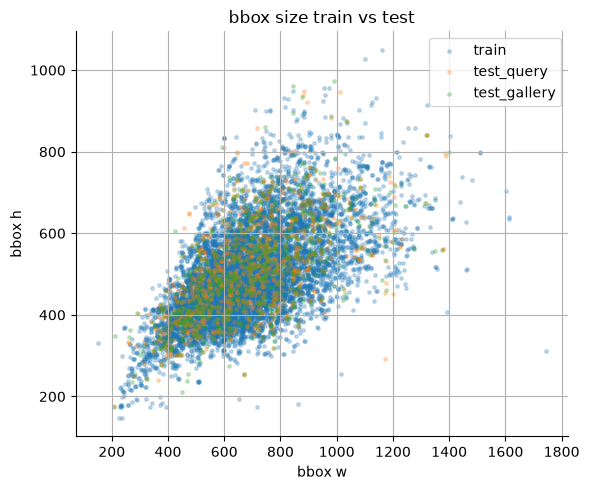

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col, title in zip(
    axes[0], ["w", "h", "aspect"], ["bbox width", "bbox height", "bbox aspect w/h"], strict=True
):
    for name, df in geom.items():
        ax.hist(df[col], bins=40, alpha=0.45, density=True, label=name)
    ax.set_title(title)
    ax.legend(fontsize=8)
for ax, col, title in zip(
    axes[1],
    ["coverage", "cx", "cy"],
    ["bbox / frame area", "bbox center x (norm)", "bbox center y (norm)"],
    strict=True,
):
    for name, df in geom.items():
        ax.hist(df[col], bins=40, alpha=0.45, density=True, label=name)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for name, df in geom.items():
    ax.scatter(df.w, df.h, s=6, alpha=0.25, label=name)
ax.set_xlabel("bbox w")
ax.set_ylabel("bbox h")
ax.set_title("bbox size train vs test")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Crop examples


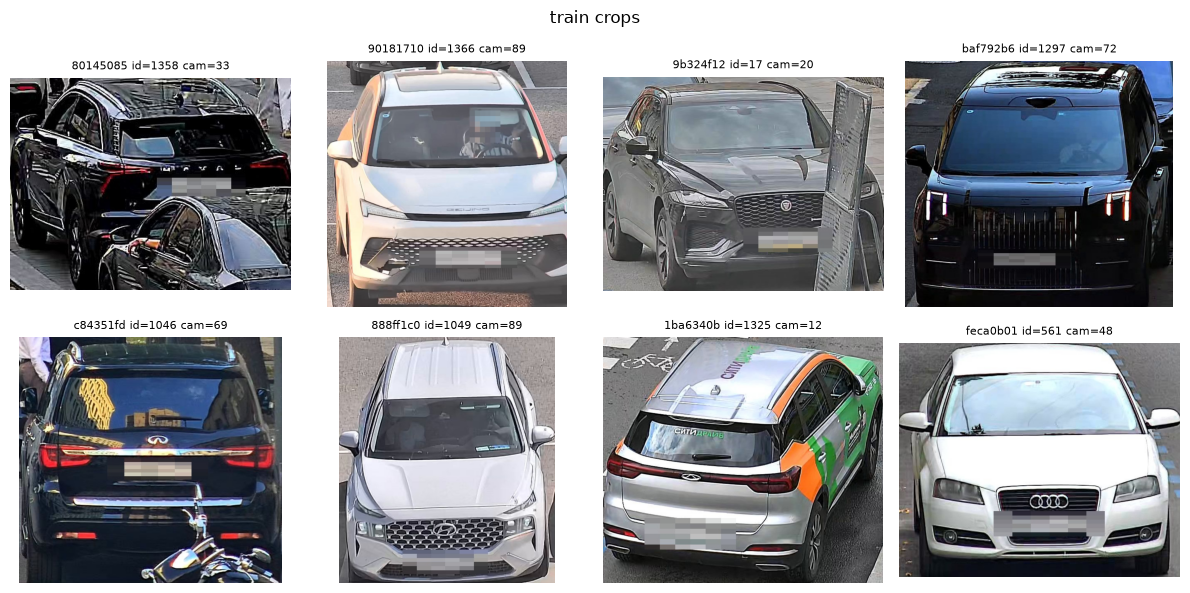

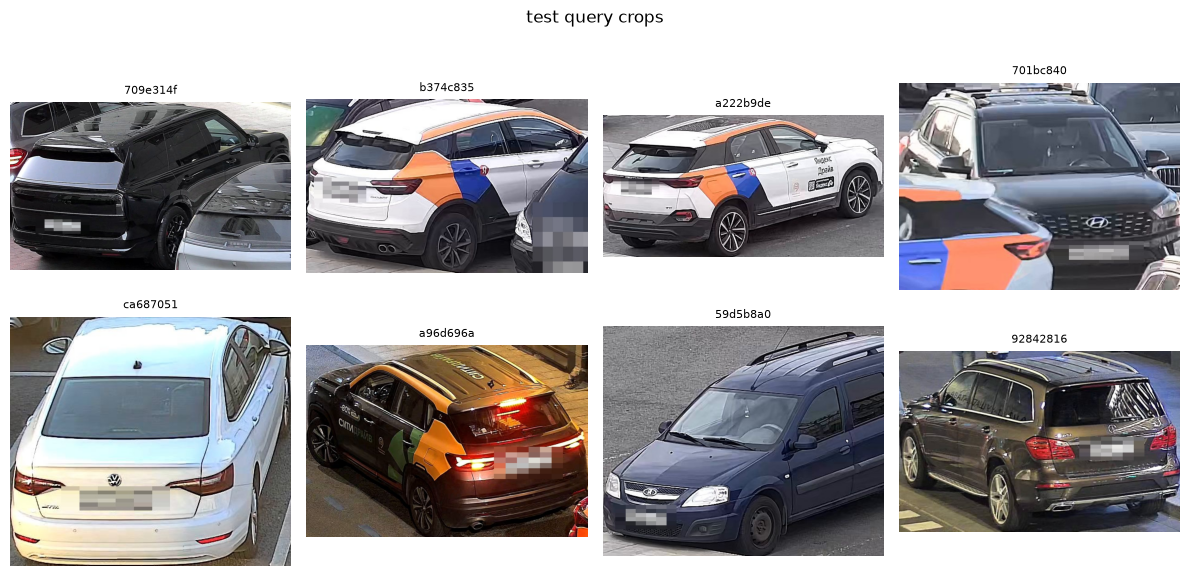

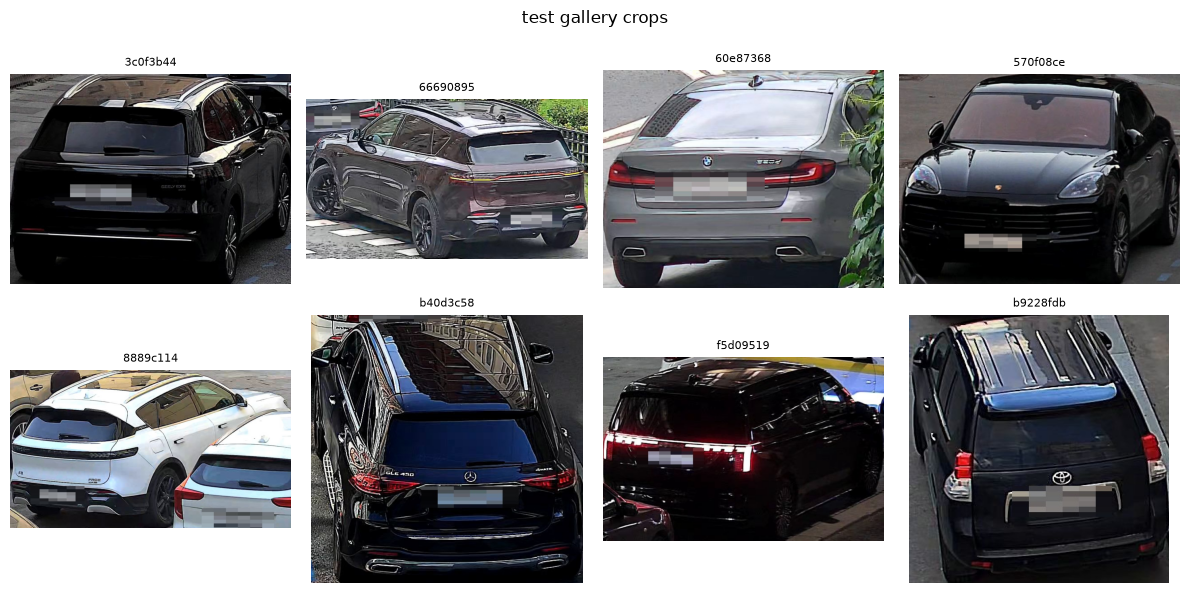

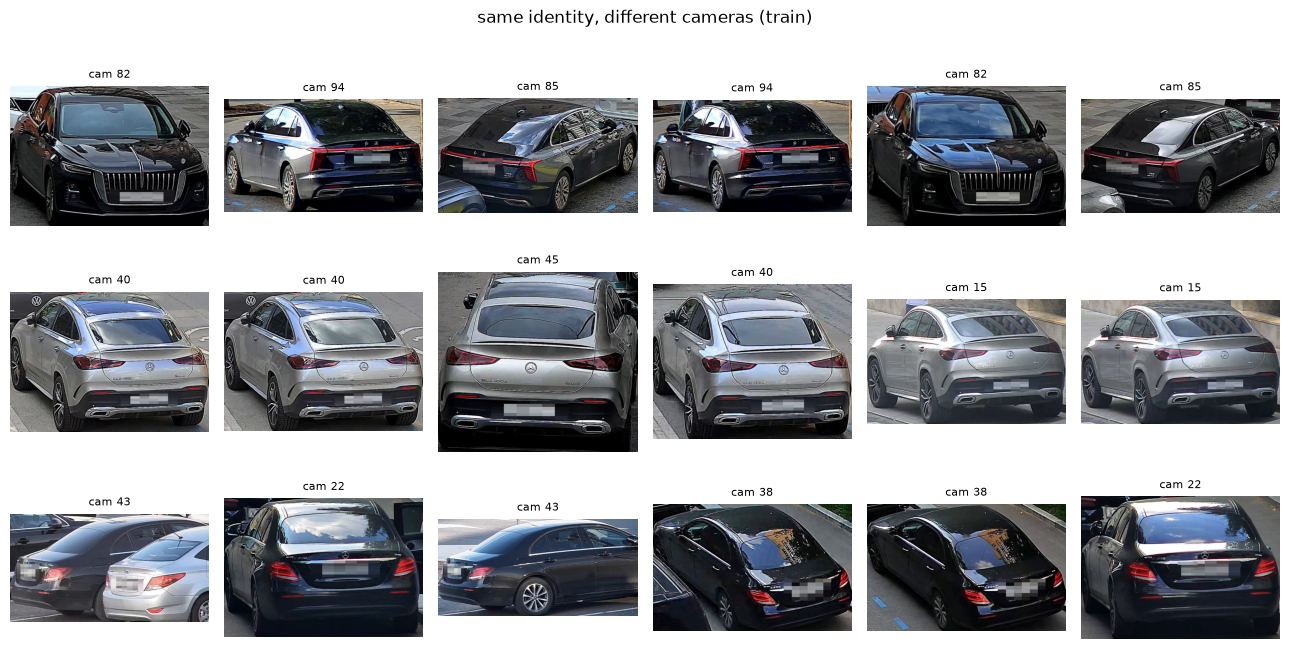

In [8]:
def show_crops(df, image_dir, title, n=8, seed=0):
    pick = df.sample(n=min(n, len(df)), random_state=seed)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, row in zip(axes.ravel(), pick.to_dict("records"), strict=True):
        with Image.open(image_path(image_dir, row["image_id"])) as im:
            crop = crop_bbox(im.convert("RGB"), [row["x"], row["y"], row["w"], row["h"]], context_pct=0)
        ax.imshow(crop)
        ax.set_axis_off()
        extra = f" id={row['vehicle_id']} cam={row['camera_id']}" if "vehicle_id" in row else ""
        ax.set_title(f"{row['image_id'][:8]}{extra}", fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


show_crops(train, IMAGES, "train crops", seed=0)
show_crops(query, IMAGES, "test query crops", seed=1)
show_crops(gallery, IMAGES, "test gallery crops", seed=2)

identities = train.vehicle_id.value_counts().index[:3]
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
for r, vid in enumerate(identities):
    rows = train[train.vehicle_id == vid].head(6)
    for c, row in enumerate(rows.to_dict("records")):
        with Image.open(image_path(IMAGES, row["image_id"])) as im:
            crop = crop_bbox(im.convert("RGB"), [row["x"], row["y"], row["w"], row["h"]])
        axes[r, c].imshow(crop)
        axes[r, c].set_axis_off()
        axes[r, c].set_title(f"cam {row['camera_id']}", fontsize=8)
    for c in range(len(rows), 6):
        axes[r, c].set_axis_off()
    axes[r, 0].set_ylabel(f"id {vid}", fontsize=9)
fig.suptitle("same identity, different cameras (train)")
fig.tight_layout()
plt.show()

## 5. Train vs test: domain and photometry


,mean_r,mean_g,mean_b,brightness,std
split,,,,,
test_gallery,101.702637,100.050163,103.626312,101.786240,66.142220
test_query,99.983932,98.950645,103.061501,100.658661,66.058449
train,103.838356,102.992996,107.936966,104.912689,67.637154


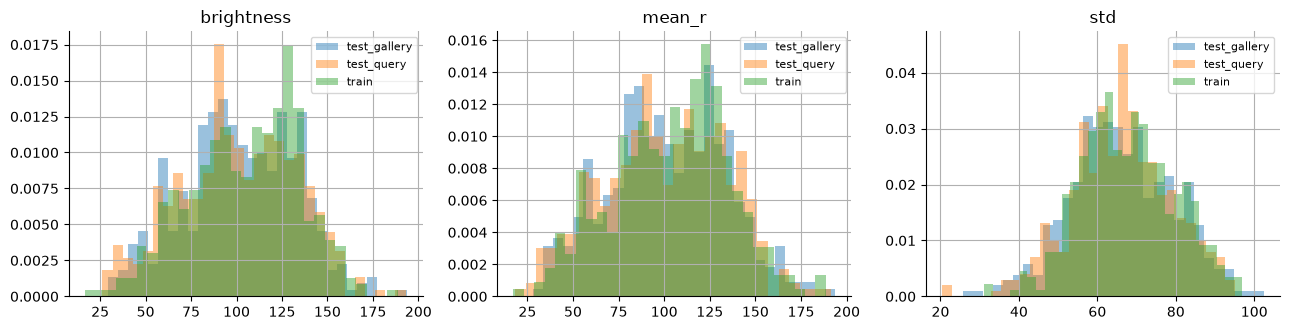

,split,images,share_of_all,labels,median_bbox_w,median_bbox_h,median_aspect,median_coverage,mean_brightness
0,train,9556,0.837071,vehicle_id + camera_id,669.0,485.0,1.356887,0.157178,104.912674
1,test_query,1110,0.097232,none,681.5,498.0,1.329918,0.162264,100.658669
2,test_gallery,750,0.065697,none,677.0,495.5,1.325116,0.161914,101.786240
3,test (q+g),1860,0.162929,none,680.5,497.0,1.329717,0.162201,101.222458


KS-like mean diffs (train minus test_query):
  w             train    689.7  query    683.9  gallery    686.6
  h             train    499.7  query    506.7  gallery    505.9
  aspect        train      1.4  query      1.4  gallery      1.4
  coverage      train      0.2  query      0.2  gallery      0.2
  frame_w       train   1920.0  query   1920.0  gallery   1920.0
  frame_h       train   1080.0  query   1080.0  gallery   1080.0


In [9]:
def sample_rgb_stats(df, image_dir, n=400, seed=0):
    pick = df.sample(n=min(n, len(df)), random_state=seed)
    means, stds, brightness = [], [], []
    for row in pick.itertuples():
        with Image.open(image_path(image_dir, row.image_id)) as im:
            crop = np.asarray(crop_bbox(im.convert("RGB"), [row.x, row.y, row.w, row.h]))
        pix = crop.reshape(-1, 3).astype(np.float32)
        means.append(pix.mean(0))
        stds.append(pix.std(0))
        brightness.append(pix.mean())
    out = pd.DataFrame(means, columns=pd.Index(["mean_r", "mean_g", "mean_b"]))
    out["brightness"] = brightness
    out["std"] = np.mean(stds, axis=1)
    out["split"] = getattr(df, "attrs", {}).get("name", "")
    return out


train_rgb = sample_rgb_stats(train, IMAGES, seed=0)
train_rgb["split"] = "train"
query_rgb = sample_rgb_stats(query, IMAGES, seed=1)
query_rgb["split"] = "test_query"
gallery_rgb = sample_rgb_stats(gallery, IMAGES, seed=2)
gallery_rgb["split"] = "test_gallery"
rgb = pd.concat([train_rgb, query_rgb, gallery_rgb], ignore_index=True)
display(rgb.groupby("split")[["mean_r", "mean_g", "mean_b", "brightness", "std"]].mean())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, ["brightness", "mean_r", "std"], strict=True):
    for name, part in rgb.groupby("split"):
        ax.hist(part[col], bins=30, alpha=0.45, density=True, label=name)
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

cmp = pd.DataFrame(
    {
        "split": ["train", "test_query", "test_gallery", "test (q+g)"],
        "images": [len(train), len(query), len(gallery), len(query) + len(gallery)],
        "share_of_all": [
            len(train) / (len(train) + len(query) + len(gallery)),
            len(query) / (len(train) + len(query) + len(gallery)),
            len(gallery) / (len(train) + len(query) + len(gallery)),
            (len(query) + len(gallery)) / (len(train) + len(query) + len(gallery)),
        ],
        "labels": ["vehicle_id + camera_id", "none", "none", "none"],
        "median_bbox_w": [
            train_g.w.median(),
            query_g.w.median(),
            gallery_g.w.median(),
            pd.concat([query_g, gallery_g]).w.median(),
        ],
        "median_bbox_h": [
            train_g.h.median(),
            query_g.h.median(),
            gallery_g.h.median(),
            pd.concat([query_g, gallery_g]).h.median(),
        ],
        "median_aspect": [
            train_g.aspect.median(),
            query_g.aspect.median(),
            gallery_g.aspect.median(),
            pd.concat([query_g, gallery_g]).aspect.median(),
        ],
        "median_coverage": [
            train_g.coverage.median(),
            query_g.coverage.median(),
            gallery_g.coverage.median(),
            pd.concat([query_g, gallery_g]).coverage.median(),
        ],
        "mean_brightness": [
            train_rgb.brightness.mean(),
            query_rgb.brightness.mean(),
            gallery_rgb.brightness.mean(),
            pd.concat([query_rgb, gallery_rgb]).brightness.mean(),
        ],
    }
)
display(cmp)

print("KS-like mean diffs (train minus test_query):")
for col in ["w", "h", "aspect", "coverage", "frame_w", "frame_h"]:
    print(
        f"  {col:12s}  train {train_g[col].mean():8.1f}"
        f"  query {query_g[col].mean():8.1f}  gallery {gallery_g[col].mean():8.1f}"
    )

**Train vs test**

- `image_id` sets are disjoint: no frame leakage.
- Test has 1860 crops (~16% of all frames); query and gallery are also disjoint.
- Bbox geometry and frame coverage are close: same capture/annotation pipeline, not a different dataset.
- Query and gallery look like train (daytime urban traffic, blurred plates).
- The important gap: test is open-set and unlabeled, and **query is longer than gallery**. Fold OOF mAP on train is not a leaderboard proxy: different IDs, different query/gallery scheme, and likely a different prior on how many gallery matches exist.


## 6. VeRi-776


                        image_id                                         image_path identity_key camera_key  full_image source
0  veri:0001_c001_00016450_0.jpg  /data/projects/ryzhichkin/ReID/extra_data/VeRi...    veri:0001  veri:c001        True   veri
1  veri:0001_c001_00016460_0.jpg  /data/projects/ryzhichkin/ReID/extra_data/VeRi...    veri:0001  veri:c001        True   veri
2  veri:0001_c001_00016470_0.jpg  /data/projects/ryzhichkin/ReID/extra_data/VeRi...    veri:0001  veri:c001        True   veri
rows 37746 ids 575 cameras 20


,count,mean,std,min,25%,50%,75%,max
n_images,575.0,65.645217,41.195413,11.0,41.0,52.0,84.5,289.0
n_cameras,575.0,8.939130,4.204459,2.0,6.0,8.0,11.0,18.0


color distribution


,images
color,
black,9207
gray,9088
white,6006
red,4358
blue,3243
green,1768
golden,1723
yellow,1311
brown,882


type distribution


,images
vtype,
sedan,19911
suv,4162
truck,3419
bus,2782
pickup,2417
van,2017
hatchback,2006
mpv,912
estate,120


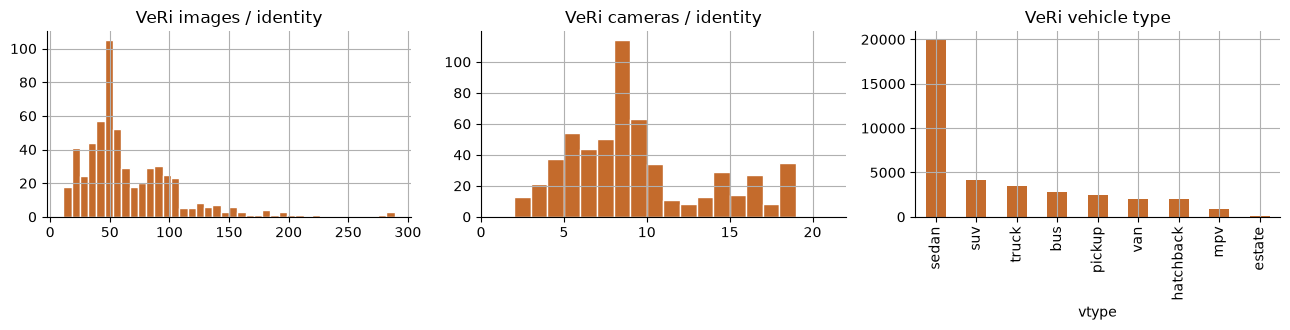

In [10]:
veri_root = EXTRA / "VeRi"
veri = read_veri(veri_root)
print(veri.head(3))
print("rows", len(veri), "ids", veri.identity_key.nunique(), "cameras", veri.camera_key.nunique())


def xml_without_declaration(text: str) -> str:
    end = text.find("?>")
    return text[end + 2 :] if end >= 0 else text


tree = ElementTree.fromstring(
    xml_without_declaration((veri_root / "train_label.xml").read_bytes().decode("gb18030"))
)
meta_rows = []
for item in tree.iter("Item"):
    meta_rows.append(
        {
            "imageName": item.attrib["imageName"],
            "vehicleID": item.attrib["vehicleID"],
            "cameraID": item.attrib["cameraID"],
            "colorID": int(item.attrib.get("colorID", 0)),
            "typeID": int(item.attrib.get("typeID", 0)),
        }
    )
veri_meta = pd.DataFrame(meta_rows)
colors = dict(
    line.split(maxsplit=1) for line in (veri_root / "list_color.txt").read_text().splitlines() if line.strip()
)
types = dict(
    line.split(maxsplit=1) for line in (veri_root / "list_type.txt").read_text().splitlines() if line.strip()
)
veri_meta["color"] = veri_meta.colorID.astype(str).map(colors)
veri_meta["vtype"] = veri_meta.typeID.astype(str).map(types)

per = veri.groupby("identity_key").agg(n_images=("image_id", "size"), n_cameras=("camera_key", "nunique"))
display(per.describe().T)
print("color distribution")
display(veri_meta.color.value_counts().to_frame("images"))
print("type distribution")
display(veri_meta.vtype.value_counts().to_frame("images"))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(per.n_images, bins=40, color="#c46b2c", edgecolor="white")
axes[0].set_title("VeRi images / identity")
axes[1].hist(per.n_cameras, bins=range(1, 22), color="#c46b2c", edgecolor="white")
axes[1].set_title("VeRi cameras / identity")
veri_meta.vtype.value_counts().plot(kind="bar", ax=axes[2], color="#c46b2c")
axes[2].set_title("VeRi vehicle type")
fig.tight_layout()
plt.show()

VeRi sampled crop size


,count,mean,std,min,25%,50%,75%,max
w,5000.0,243.71580,113.774883,57.000000,169.000000,220.500000,288.000000,1178.000000
h,5000.0,214.20800,100.287444,53.000000,142.000000,191.000000,262.000000,742.000000
aspect,5000.0,1.18949,0.338106,0.514577,0.964556,1.138788,1.341282,2.901639
area,5000.0,60753.07700,60691.313747,3564.000000,24972.750000,41872.000000,75226.250000,638792.000000


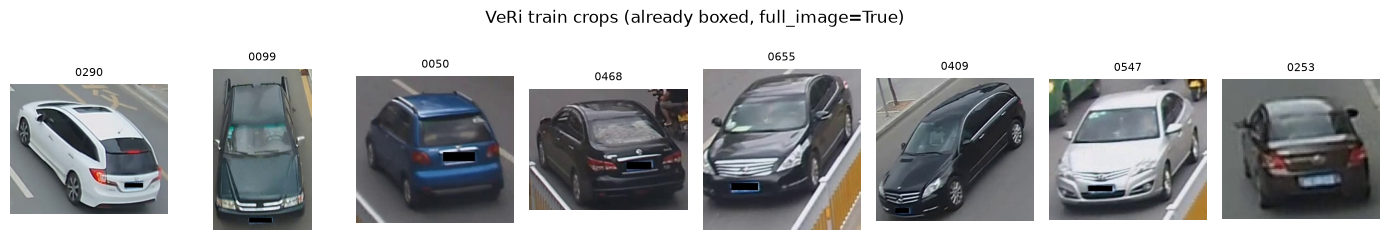

In [11]:
def sample_wh(paths, n=4000, seed=0):
    rng = np.random.default_rng(seed)
    paths = list(paths)
    if n < len(paths):
        idx = rng.choice(len(paths), size=n, replace=False)
        paths = [paths[i] for i in idx]
    ws, hs = [], []
    for path in paths:
        with Image.open(path) as im:
            ws.append(im.size[0])
            hs.append(im.size[1])
    return pd.DataFrame(
        {"w": ws, "h": hs, "aspect": np.array(ws) / np.array(hs), "area": np.array(ws) * np.array(hs)}
    )


veri_wh = sample_wh(veri.image_path, n=5000, seed=0)
print("VeRi sampled crop size")
display(veri_wh.describe().T)

fig, axes = plt.subplots(1, 8, figsize=(14, 2.4))
sample = veri.sample(8, random_state=0)
for ax, row in zip(axes, sample.to_dict("records"), strict=True):
    with Image.open(row["image_path"]) as im:
        ax.imshow(im.convert("RGB"))
    ax.set_axis_off()
    ax.set_title(row["identity_key"].split(":")[-1], fontsize=8)
fig.suptitle("VeRi train crops (already boxed, full_image=True)")
fig.tight_layout()
plt.show()

## 7. VRIC


                          image_id                                         image_path identity_key camera_key  full_image source
0  vric:MVI_40172_101_img02185.jpg  /data/projects/ryzhichkin/ReID/extra_data/VRIC...    vric:1249    vric:58        True   vric
1  vric:MVI_40172_101_img01499.jpg  /data/projects/ryzhichkin/ReID/extra_data/VRIC...    vric:1249    vric:58        True   vric
2  vric:MVI_40172_101_img02339.jpg  /data/projects/ryzhichkin/ReID/extra_data/VRIC...    vric:1249    vric:58        True   vric
rows 54808 ids 2811 cameras 120


,count,mean,std,min,25%,50%,75%,max
n_images,2811.0,19.497688,11.357515,1.0,10.0,19.0,29.0,40.0
n_cameras,2811.0,1.942369,0.233085,1.0,2.0,2.0,2.0,2.0


single-camera identities 162
official VRIC probe/gallery 2811 2811 id overlap train/probe 0


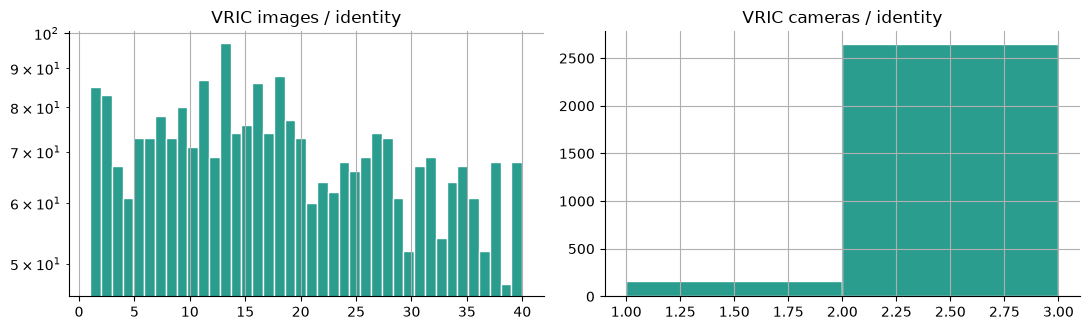

VRIC sampled crop size


,count,mean,std,min,25%,50%,75%,max
w,5000.0,102.751400,66.141325,24.000000,54.000000,84.0,131.000000,676.000000
h,5000.0,65.770800,37.452802,24.000000,39.000000,55.0,82.000000,413.000000
aspect,5000.0,1.581266,0.550001,0.326797,1.153846,1.5,1.917864,6.705882
area,5000.0,8644.997200,10947.863007,576.000000,2142.000000,4710.0,10248.000000,175760.000000


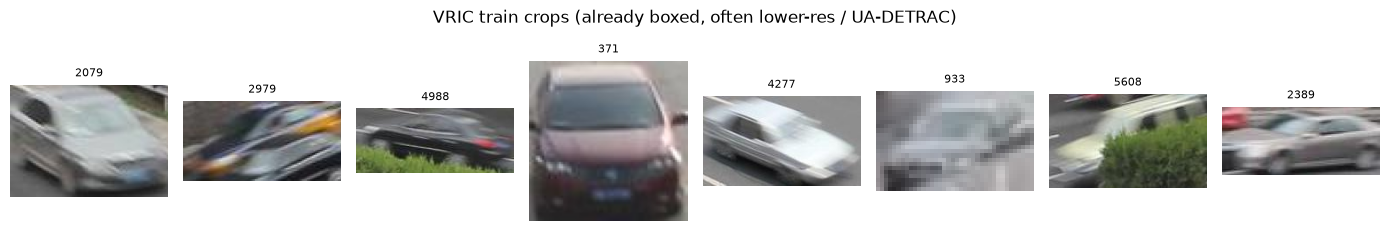

In [12]:
vric_root = EXTRA / "VRIC"
vric = read_vric(vric_root)
print(vric.head(3))
print("rows", len(vric), "ids", vric.identity_key.nunique(), "cameras", vric.camera_key.nunique())
per_v = vric.groupby("identity_key").agg(n_images=("image_id", "size"), n_cameras=("camera_key", "nunique"))
display(per_v.describe().T)
print("single-camera identities", int((per_v.n_cameras == 1).sum()))

probe = pd.read_csv(
    vric_root / "vric_probe.txt", sep=r"\s+", header=None, names=["image", "identity", "camera"]
)
gall = pd.read_csv(
    vric_root / "vric_gallery.txt", sep=r"\s+", header=None, names=["image", "identity", "camera"]
)
print(
    "official VRIC probe/gallery",
    len(probe),
    len(gall),
    "id overlap train/probe",
    len(set(vric.identity_key.str.split(":").str[-1]) & set(probe.identity.astype(str))),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(per_v.n_images, bins=40, color="#2a9d8f", edgecolor="white")
axes[0].set_title("VRIC images / identity")
axes[0].set_yscale("log")
axes[1].hist(
    per_v.n_cameras, bins=range(1, int(per_v.n_cameras.max()) + 2), color="#2a9d8f", edgecolor="white"
)
axes[1].set_title("VRIC cameras / identity")
fig.tight_layout()
plt.show()

vric_wh = sample_wh(vric.image_path, n=5000, seed=1)
print("VRIC sampled crop size")
display(vric_wh.describe().T)

fig, axes = plt.subplots(1, 8, figsize=(14, 2.4))
sample = vric.sample(8, random_state=1)
for ax, row in zip(axes, sample.to_dict("records"), strict=True):
    with Image.open(row["image_path"]) as im:
        ax.imshow(im.convert("RGB"))
    ax.set_axis_off()
    ax.set_title(row["identity_key"].split(":")[-1], fontsize=8)
fig.suptitle("VRIC train crops (already boxed, often lower-res / UA-DETRAC)")
fig.tight_layout()
plt.show()

## 8. Competition vs VeRi vs VRIC


,dataset,images,identities,cameras,images_per_id_median,cameras_per_id_median,median_w,median_h,median_area,crop_source,labels,images_vs_train,ids_vs_train
0,competition train,9556,1541.0,96.0,6.0,2.0,669.0,485.0,325924.5,bbox on full frame,vehicle + camera,1.000000,1.000000
1,competition test,1860,NaN,NaN,NaN,NaN,680.5,497.0,336340.0,bbox on full frame,none,0.194642,NaN
2,VeRi train,37746,575.0,20.0,52.0,8.0,220.5,191.0,41872.0,pre-cropped,vehicle + camera + color/type,3.949979,0.373134
3,VRIC train,54808,2811.0,120.0,19.0,2.0,84.0,55.0,4710.0,pre-cropped,vehicle + camera,5.735454,1.824140


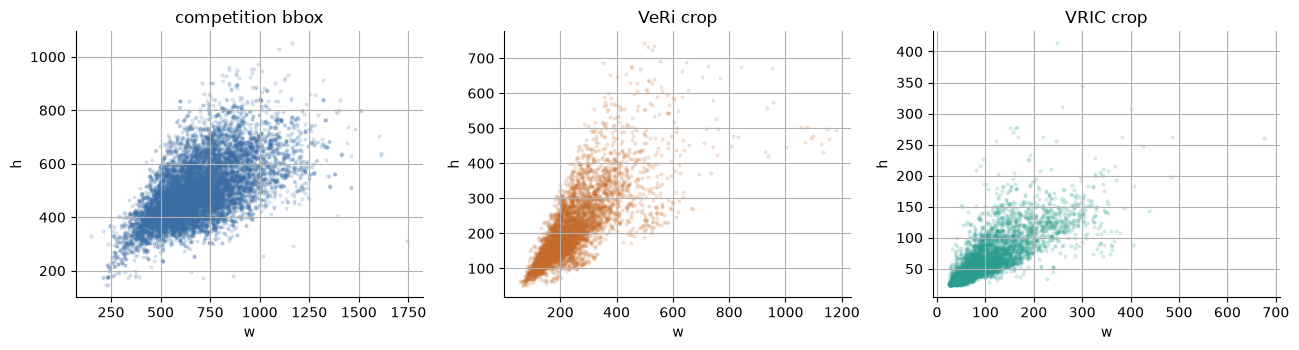

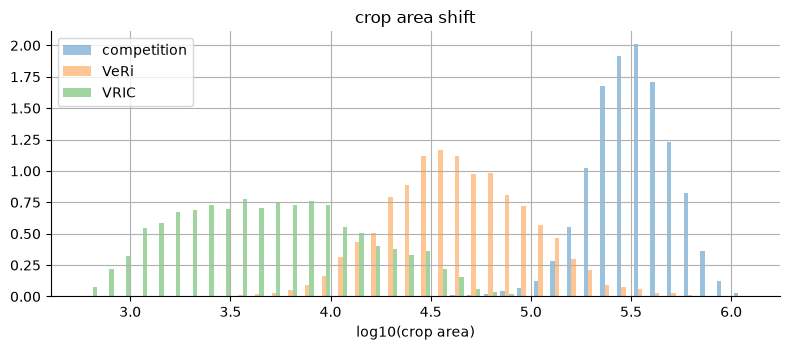

area ratios vs competition train median bbox
  VeRi / orig  0.1284714711535954
  VRIC / orig  0.014451199587634559
  test / orig  1.0319567875382183
image count ratios vs train
  VeRi 3.9499790707408957 VRIC 5.735454164922562 test 0.19464210966931772


In [13]:
comp_wh = pd.DataFrame(
    {
        "w": pd.concat([train_g.w, query_g.w, gallery_g.w], ignore_index=True),
        "h": pd.concat([train_g.h, query_g.h, gallery_g.h], ignore_index=True),
    }
)
comp_wh["aspect"] = comp_wh.w / comp_wh.h
comp_wh["area"] = comp_wh.w * comp_wh.h

summary = pd.DataFrame(
    [
        {
            "dataset": "competition train",
            "images": len(train),
            "identities": train.vehicle_id.nunique(),
            "cameras": train.camera_id.nunique(),
            "images_per_id_median": float(train.groupby("vehicle_id").size().median()),
            "cameras_per_id_median": float(train.groupby("vehicle_id").camera_id.nunique().median()),
            "median_w": float(train_g.w.median()),
            "median_h": float(train_g.h.median()),
            "median_area": float(train_g.bbox_area.median()),
            "crop_source": "bbox on full frame",
            "labels": "vehicle + camera",
        },
        {
            "dataset": "competition test",
            "images": len(query) + len(gallery),
            "identities": np.nan,
            "cameras": np.nan,
            "images_per_id_median": np.nan,
            "cameras_per_id_median": np.nan,
            "median_w": float(pd.concat([query_g.w, gallery_g.w]).median()),
            "median_h": float(pd.concat([query_g.h, gallery_g.h]).median()),
            "median_area": float(pd.concat([query_g.bbox_area, gallery_g.bbox_area]).median()),
            "crop_source": "bbox on full frame",
            "labels": "none",
        },
        {
            "dataset": "VeRi train",
            "images": len(veri),
            "identities": veri.identity_key.nunique(),
            "cameras": veri.camera_key.nunique(),
            "images_per_id_median": float(per.n_images.median()),
            "cameras_per_id_median": float(per.n_cameras.median()),
            "median_w": float(veri_wh.w.median()),
            "median_h": float(veri_wh.h.median()),
            "median_area": float(veri_wh.area.median()),
            "crop_source": "pre-cropped",
            "labels": "vehicle + camera + color/type",
        },
        {
            "dataset": "VRIC train",
            "images": len(vric),
            "identities": vric.identity_key.nunique(),
            "cameras": vric.camera_key.nunique(),
            "images_per_id_median": float(per_v.n_images.median()),
            "cameras_per_id_median": float(per_v.n_cameras.median()),
            "median_w": float(vric_wh.w.median()),
            "median_h": float(vric_wh.h.median()),
            "median_area": float(vric_wh.area.median()),
            "crop_source": "pre-cropped",
            "labels": "vehicle + camera",
        },
    ]
)
summary["images_vs_train"] = summary.images / len(train)
summary["ids_vs_train"] = summary.identities / train.vehicle_id.nunique()
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, df, title, color in [
    (axes[0], comp_wh, "competition bbox", "#3b6ea5"),
    (axes[1], veri_wh, "VeRi crop", "#c46b2c"),
    (axes[2], vric_wh, "VRIC crop", "#2a9d8f"),
]:
    ax.scatter(df.w, df.h, s=4, alpha=0.15, c=color)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.set_ylabel("h")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.6))
parts = [("competition", comp_wh.area), ("VeRi", veri_wh.area), ("VRIC", vric_wh.area)]
ax.hist([np.log10(p[1]) for p in parts], bins=40, density=True, alpha=0.45, label=[p[0] for p in parts])
ax.set_xlabel("log10(crop area)")
ax.set_title("crop area shift")
ax.legend()
fig.tight_layout()
plt.show()

print("area ratios vs competition train median bbox")
base = train_g.bbox_area.median()
print("  VeRi / orig ", veri_wh.area.median() / base)
print("  VRIC / orig ", vric_wh.area.median() / base)
print("  test / orig ", pd.concat([query_g.bbox_area, gallery_g.bbox_area]).median() / base)
print("image count ratios vs train")
print(
    "  VeRi",
    len(veri) / len(train),
    "VRIC",
    len(vric) / len(train),
    "test",
    (len(query) + len(gallery)) / len(train),
)

### Training takeaways

1. **Competition data** is a small dense open-set: ~6 images per vehicle, always ≥2 cameras, 96 cameras. Test is the same visual domain, but unlabeled, with an inverted query/gallery balance.
2. Progress **cannot** be measured on the official test locally. The working metric is identity-disjoint OOF on train.
3. **VeRi** is closer as a task (multi-camera, already cropped, color/type tags). It has ~4× more images than train and fewer identities (576 vs 1541). Pretraining on VeRi is the same task in a different city/camera layout.
4. **VRIC** is larger still (~5.7× train, 2811 IDs), but it comes from UA-DETRAC: lower resolution, different optics, some single-camera IDs. VRIC pretrain on the trial-23 recipe **hurt** the competition-train probe; VeRi was weak but less harmful.
5. Extra data in `pretrain.py` is already cropped (`full_image=True`); competition bboxes are not applied. Sources can be mixed: identity/camera keys are prefixed `veri:` / `vric:`.
6. Mad-cars is out of scope here: the lab pretrain path uses VeRi and VRIC only.
